# Pipeline WLASL

Pipeline completo basado en `glosses_valid.json`. Ejecutar las celdas en orden.
Modificar los hiperparámetros de la primera celda antes de comenzar.

In [24]:
import os
import sys
import shutil
import logging
import subprocess
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

# ── Directorios ──────────────────────────────────────────────────────────────
NB_DIR         = Path().resolve()           # WLASL/code/
WLASL_DIR      = NB_DIR.parent             # WLASL/
START_KIT      = WLASL_DIR / "start_kit"
I3D_DIR        = NB_DIR / "I3D"

RAW_VIDEOS_DIR = START_KIT / "raw_videos"       # videos descargados (raw)
RAW_VIDEOS_MP4 = START_KIT / "raw_videos_mp4"   # videos convertidos a mp4
VIDEOS_DIR     = START_KIT / "videos"            # videos preprocesados (finales)

# ── Archivos JSON ────────────────────────────────────────────────────────────
WLASL_FULL_JSON    = START_KIT / "WLASL_v0.3.full.json"
GLOSSES_VALID_JSON = START_KIT / "glosses_valid.json"
CORRUPTED_TXT      = START_KIT / "corrupted.txt"
MISSING_TXT        = START_KIT / "missing.txt"
NSLT_JSON          = I3D_DIR / "preprocess" / "nslt_valid.json"
NSLT_AUG_JSON      = I3D_DIR / "preprocess" / "nslt_valid_aug.json"

# ── Filtro de glosses
TOP_N_GLOSSES = 20          # None para usar todos

# ── Augmentation ─────────────────────────────────────────────────────────────
AUG_WORKERS   = max(1, os.cpu_count() - 2)
AUG_SCALE_MIN = 0.5
AUG_SCALE_MAX = 2.0
AUG_SEED      = 42

# ── Importar funciones reutilizables de start_kit ────────────────────────────
if str(START_KIT) not in sys.path:
    sys.path.insert(0, str(START_KIT))

from glosses import main as generate_glosses_valid, build_nslt_json
from video_downloader import download_nonyt_videos, download_yt_videos
from preprocess import video_to_frames, convert_frames_to_video, extract_frame_as_video
from utils import plot_class_distribution, show_augmentation_example

print("Configuración cargada:")
for name, val in [
    ("NB_DIR", NB_DIR), ("START_KIT", START_KIT),
    ("VIDEOS_DIR", VIDEOS_DIR), ("NSLT_JSON", NSLT_JSON),
    ("NSLT_AUG_JSON", NSLT_AUG_JSON), ("AUG_WORKERS", AUG_WORKERS),
]:
    print(f"  {name}: {val}")

Configuración cargada:
  NB_DIR: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code
  START_KIT: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit
  VIDEOS_DIR: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit/videos
  NSLT_JSON: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/preprocess/nslt_valid.json
  NSLT_AUG_JSON: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/preprocess/nslt_valid_aug.json
  AUG_WORKERS: 10


## Paso 1 — Generar `glosses_valid.json`

Filtra de `WLASL_v0.3.full.json` los videos que aparezcan en `corrupted.txt` o `missing.txt`
y guarda el resultado en `glosses_valid.json`.

In [2]:
generate_glosses_valid()

Guardado: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit/glosses_valid.json (1999 glosses, 10237 instancias válidas)

Rank   Gloss                          Videos   IDs
--------------------------------------------------------------------------------
1      computer                       16       12306, 68028, 12329, 12312, 12331, 12333, 12335, 12311, 12313, 12314, 12315, 12316, 12317, 12318, 12319, 12320
2      drink                          14       69302, 70173, 68042, 68041, 17725, 17728, 17710, 17729, 17730, 17731, 17711, 17712, 17713, 17709
3      before                         14       05724, 70348, 68007, 05744, 05746, 05728, 05747, 05729, 05730, 05731, 05732, 05733, 05734, 05727
4      hot                            14       28074, 69368, 70270, 28108, 28109, 28110, 28111, 28112, 28107, 28118, 28119, 28120, 28121, 28122
5      like                           14       69389, 33266, 68093, 70299, 33267, 33268, 33269, 33270, 33277, 33278, 33279, 33280, 33281, 33282
6 

## Paso 1b — Filtrar a top N glosses

Reescribe  con solo los  glosses con más instancias.
Poner  en la primera celda para usar todos.

In [3]:
if TOP_N_GLOSSES is not None:
    import json as _json
    _data = _json.loads(GLOSSES_VALID_JSON.read_text())
    _sorted = sorted(_data, key=lambda e: len(e["instances"]), reverse=True)
    _top = _sorted[:TOP_N_GLOSSES]
    GLOSSES_VALID_JSON.write_text(_json.dumps(_top, indent=2, ensure_ascii=False))
    total = sum(len(e["instances"]) for e in _top)
    print(f"Filtrado a top {TOP_N_GLOSSES} glosses: {total} instancias")
    for e in _top:
        print(f"  {e['gloss']}: {len(e['instances'])} videos")
else:
    print("TOP_N_GLOSSES = None, usando todos los glosses")


Filtrado a top 20 glosses: 259 instancias
  computer: 16 videos
  drink: 14 videos
  before: 14 videos
  hot: 14 videos
  like: 14 videos
  who: 13 videos
  deaf: 13 videos
  yes: 13 videos
  mother: 13 videos
  hearing: 13 videos
  white: 13 videos
  wrong: 13 videos
  candy: 12 videos
  no: 12 videos
  thin: 12 videos
  finish: 12 videos
  now: 12 videos
  orange: 12 videos
  study: 12 videos
  bird: 12 videos


## Paso 2 — Descargar videos (no YouTube)

Descarga todos los videos directos (no YouTube) a `RAW_VIDEOS_DIR`.
Los videos ya descargados se saltean automáticamente.

In [4]:
RAW_VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
download_nonyt_videos(str(GLOSSES_VALID_JSON), str(RAW_VIDEOS_DIR))

INFO: gloss: computer, video: 12306.


gloss: computer, video: 12306.


Skipping YouTube video 12306


INFO: gloss: computer, video: 68028.


gloss: computer, video: 68028.


...

Requesting https://media.spreadthesign.com/video/mp4/13/124323.mp4


INFO: gloss: bird, video: 06332.


gloss: bird, video: 06332.


INFO: Requesting https://s3-us-west-1.amazonaws.com/files.startasl.com/asldictionary/bird.mp4


Requesting https://s3-us-west-1.amazonaws.com/files.startasl.com/asldictionary/bird.mp4


## Paso 3 — Descargar videos de YouTube

Requiere `yt-dlp` instalado (`pip install yt-dlp`).
Los videos se guardan en `RAW_VIDEOS_DIR` con el ID de YouTube como nombre.

In [5]:
RAW_VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
download_yt_videos(str(GLOSSES_VALID_JSON), str(RAW_VIDEOS_DIR))

         It is strongly recommended to always use the latest version.
         You installed yt-dlp with pip or using the wheel from PyPi; Use that to update.
         To suppress this warning, add --no-update to your command/config.


[youtube] Extracting URL: https://www.youtube.com/watch?v=PPmQd2zWdP0
[youtube] PPmQd2zWdP0: Downloading webpage


[youtube] PPmQd2zWdP0: Downloading android vr player API JSON
[info] PPmQd2zWdP0: Downloading 1 format(s): 18
[download] Destination: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit/raw_videos/PPmQd2zWdP0.mp4
[download]  91.0% of   11.27MiB at    2.33MiB/s ETA 00:00  

INFO: Finish downloading youtube video url https://www.youtube.com/watch?v=PPmQd2zWdP0


[download] 100% of   11.27MiB in 00:00:21 at 540.67KiB/s 
Finish downloading youtube video url https://www.youtube.com/watch?v=PPmQd2zWdP0


...

         It is strongly recommended to always use the latest version.
         You installed yt-dlp with pip or using the wheel from PyPi; Use that to update.
         To suppress this warning, add --no-update to your command/config.


[youtube] Extracting URL: https://www.youtube.com/watch?v=o9GSFqvikro
[youtube] o9GSFqvikro: Downloading webpage


[youtube] o9GSFqvikro: Downloading android vr player API JSON
[info] o9GSFqvikro: Downloading 1 format(s): 18


INFO: Finish downloading youtube video url https://www.youtube.com/watch?v=o9GSFqvikro


[download] Destination: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit/raw_videos/o9GSFqvikro.mp4
[download] 100% of  185.83KiB in 00:00:01 at 105.01KiB/s   
Finish downloading youtube video url https://www.youtube.com/watch?v=o9GSFqvikro


## Chequeo de descargas

## Paso 3b — Sincronizar glosses_valid.json con archivos descargados

Elimina de `glosses_valid.json` las instancias cuyos videos no se pudieron descargar.

In [13]:
import json as _json

_data = _json.loads(GLOSSES_VALID_JSON.read_text())
_removed = 0
_synced = []

for entry in _data:
    valid = []
    for inst in entry["instances"]:
        url = inst["url"]
        vid_id = inst["video_id"]
        if "youtube" in url or "youtu.be" in url:
            yt_id = url.split("v=")[-1].split("&")[0] if "v=" in url else url[-11:]
            found = any((RAW_VIDEOS_DIR / f"{yt_id}{ext}").exists() for ext in [".mp4", ".mkv", ".webm"])
        elif "aslpro" in url:
            found = (RAW_VIDEOS_DIR / f"{vid_id}.swf").exists()
        else:
            found = (RAW_VIDEOS_DIR / f"{vid_id}.mp4").exists()
        if found:
            valid.append(inst)
        else:
            _removed += 1
    if valid:
        _synced.append({**entry, "instances": valid})

GLOSSES_VALID_JSON.write_text(_json.dumps(_synced, indent=2, ensure_ascii=False))
total = sum(len(e["instances"]) for e in _synced)
print(f"Eliminadas: {_removed} instancias | Quedan: {total} videos en {len(_synced)} glosses")


Eliminadas: 9 instancias | Quedan: 250 videos en 20 glosses


In [14]:
import json as _json
from collections import Counter

_data = _json.loads(GLOSSES_VALID_JSON.read_text())
_ok, _missing = [], []

for entry in _data:
    for inst in entry["instances"]:
        url = inst["url"]
        vid_id = inst["video_id"]
        if "youtube" in url or "youtu.be" in url:
            yt_id = url.split("v=")[-1].split("&")[0] if "v=" in url else url[-11:]
            found = any((RAW_VIDEOS_DIR / f"{yt_id}{ext}").exists() for ext in [".mp4", ".mkv", ".webm"])
        elif "aslpro" in url:
            found = (RAW_VIDEOS_DIR / f"{vid_id}.swf").exists()
        else:
            found = (RAW_VIDEOS_DIR / f"{vid_id}.mp4").exists()
        ((_ok if found else _missing)).append((entry["gloss"], vid_id))

_ok_by = Counter(g for g, _ in _ok)
_miss_by = Counter(g for g, _ in _missing)
all_glosses = sorted({g for g, _ in _ok + _missing})
print(f"Descargados: {len(_ok)} | Faltantes: {len(_missing)}")
print()
print(f"  {'Gloss':<20} {'OK':<6} {'Faltantes'}")
print("  " + "-" * 38)
for g in all_glosses:
    print(f"  {g:<20} {_ok_by[g]:<6} {_miss_by[g]}")


Descargados: 250 | Faltantes: 0

  Gloss                OK     Faltantes
  --------------------------------------
  before               14     0
  bird                 12     0
  candy                11     0
  computer             16     0
  deaf                 10     0
  drink                13     0
  finish               12     0
  hearing              13     0
  hot                  14     0
  like                 14     0
  mother               13     0
  no                   11     0
  now                  11     0
  orange               11     0
  study                12     0
  thin                 12     0
  white                13     0
  who                  12     0
  wrong                13     0
  yes                  13     0


## Paso 4 — Convertir todos los videos a MP4

Convierte archivos `.swf` y `.mkv` de `RAW_VIDEOS_DIR` a `.mp4` en `RAW_VIDEOS_MP4`.
Los archivos que ya son MP4 se copian directamente.
Requiere `ffmpeg` instalado.

In [15]:
RAW_VIDEOS_MP4.mkdir(parents=True, exist_ok=True)

src_files = list(RAW_VIDEOS_DIR.iterdir())
total = len(src_files)
ok, skipped, failed = 0, 0, 0

for i, src in enumerate(src_files, 1):
    dst = RAW_VIDEOS_MP4 / (src.stem + ".mp4")
    if dst.exists():
        skipped += 1
        continue

    if src.suffix.lower() == ".mp4":
        shutil.copy2(src, dst)
        ok += 1
    else:
        rv = subprocess.run(
            ["ffmpeg", "-loglevel", "panic", "-i", str(src),
             "-vf", "pad=width=ceil(iw/2)*2:height=ceil(ih/2)*2", str(dst)],
            capture_output=True
        )
        if rv.returncode == 0:
            ok += 1
        else:
            logging.error(f"ffmpeg falló en {src.name}")
            failed += 1

    if i % 200 == 0:
        print(f"  {i}/{total} procesados")

print(f"Conversión MP4 — OK: {ok} | Ya existían: {skipped} | Fallidos: {failed}")

Conversión MP4 — OK: 0 | Ya existían: 400 | Fallidos: 0


## Paso 5 — Preprocesamiento: extraer instancias

- **Videos de YouTube**: extrae el segmento de frames definido por `frame_start`/`frame_end`.
- **Resto**: copia directamente de `RAW_VIDEOS_MP4` a `VIDEOS_DIR` con el `video_id` como nombre.

In [16]:
import json

VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
content = json.loads(GLOSSES_VALID_JSON.read_text())
ok, skipped, failed = 0, 0, 0

for entry in content:
    for inst in entry["instances"]:
        url    = inst["url"]
        vid_id = inst["video_id"]
        dst    = VIDEOS_DIR / f"{vid_id}.mp4"

        if dst.exists():
            skipped += 1
            continue

        if "youtube" in url or "youtu.be" in url:
            yt_id = url.split("v=")[-1].split("&")[0] if "v=" in url else url[-11:]
            src   = RAW_VIDEOS_MP4 / f"{yt_id}.mp4"
            if not src.exists():
                failed += 1
                continue
            start = inst["frame_start"] - 1
            end   = inst["frame_end"] - 1
            if end <= 0:
                shutil.copy2(src, dst)
            else:
                selected = extract_frame_as_video(str(src), start, end)
                size = selected[0].shape[:2][::-1]
                convert_frames_to_video(selected, str(dst), size)
        else:
            src = RAW_VIDEOS_MP4 / f"{vid_id}.mp4"
            if not src.exists():
                failed += 1
                continue
            shutil.copy2(src, dst)

        ok += 1

print(f"Preprocesamiento — OK: {ok} | Ya existían: {skipped} | Fallidos: {failed}")
print(f"Videos en {VIDEOS_DIR}: {len(list(VIDEOS_DIR.glob('*.mp4')))}")

Preprocesamiento — OK: 0 | Ya existían: 250 | Fallidos: 0
Videos en /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit/videos: 250


## Paso 6 — Construir JSON formato NSLT

Convierte `glosses_valid.json` al formato que espera el modelo I3D:
```
{ "video_id": { "subset": "train", "action": [class_id, frame_start, frame_end] } }
```
El `class_id` corresponde al índice del gloss en el archivo JSON (orden original).

In [17]:
build_nslt_json(GLOSSES_VALID_JSON, NSLT_JSON)

NSLT JSON guardado: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/preprocess/nslt_valid.json
  Total: 250 videos
  test: 36
  train: 171
  val: 43


{'12306': {'subset': 'test', 'action': [0, 5122, 5181]},
 '68028': {'subset': 'train', 'action': [0, 1, -1]},
 '12329': {'subset': 'train', 'action': [0, 1, -1]},
 '12312': {'subset': 'val', 'action': [0, 1, -1]},
 '12331': {'subset': 'train', 'action': [0, 1, -1]},
 '12333': {'subset': 'val', 'action': [0, 1, -1]},
 '12335': {'subset': 'val', 'action': [0, 1, -1]},
 '12311': {'subset': 'train', 'action': [0, 1, -1]},
 '12313': {'subset': 'train', 'action': [0, 1, -1]},
 '12314': {'subset': 'train', 'action': [0, 1, -1]},
 '12315': {'subset': 'val', 'action': [0, 1, -1]},
 '12316': {'subset': 'train', 'action': [0, 1, -1]},
 '12317': {'subset': 'train', 'action': [0, 1, -1]},
 '12318': {'subset': 'train', 'action': [0, 1, -1]},
 '12319': {'subset': 'train', 'action': [0, 1, -1]},
 '12320': {'subset': 'test', 'action': [0, 1, -1]},
 '69302': {'subset': 'val', 'action': [1, 1, -1]},
 '70173': {'subset': 'val', 'action': [1, 5710, 5831]},
 '68042': {'subset': 'val', 'action': [1, 1, -1]},

## Distribución de clases

Tabla y gráfico de barras apiladas con la cantidad de instancias por gloss y split (train / val / test).

Gloss                                Train    Val   Test   Total
--------------------------------------------------------------
computer                                10      4      2      16
before                                  12      1      1      14
like                                     9      3      2      14
hot                                      8      3      3      14
hearing                                 10      2      1      13
wrong                                   10      2      1      13
white                                    9      2      2      13
mother                                  10      1      2      13
drink                                    9      3      1      13
yes                                      8      3      2      13
finish                                   7      2      3      12
bird                                     7      3      2      12
study                                    9      2      1      12
thin                       

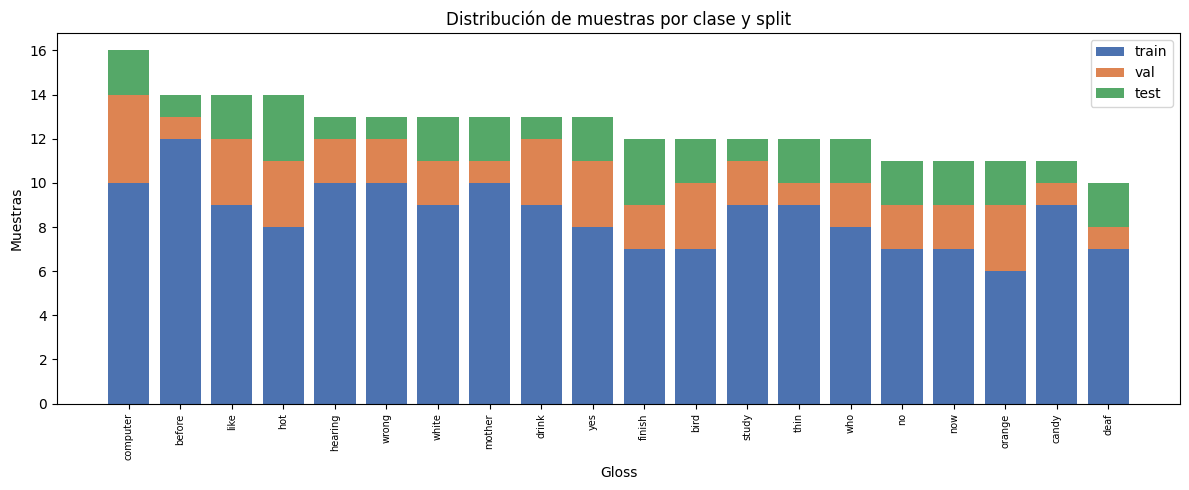

split,train,val,test,total
gloss,,,,
computer,10,4,2,16
before,12,1,1,14
like,9,3,2,14
hot,8,3,3,14
hearing,10,2,1,13
wrong,10,2,1,13
white,9,2,2,13
mother,10,1,2,13
drink,9,3,1,13


In [18]:
plot_class_distribution(GLOSSES_VALID_JSON)

## Paso 7 — Data Augmentation

Genera 2 copias augmentadas por cada video de **entrenamiento**:
- `<id>t.mp4` — temporal rescale (velocidad aleatoria entre `AUG_SCALE_MIN` y `AUG_SCALE_MAX`)
- `<id>f.mp4` — filtro visual (brillo, contraste, ruido, blur, etc.)

Las copias se guardan en `VIDEOS_DIR` y el JSON ampliado en `NSLT_AUG_JSON`.

Requiere `albumentations` y `scipy` instalados.

In [20]:
augment_script = I3D_DIR / "augment_offline.py"

cmd = [
    sys.executable, str(augment_script),
    "--json",      str(NSLT_JSON),
    "--vid-root",  str(VIDEOS_DIR),
    "--out-json",  str(NSLT_AUG_JSON),
    "--workers",   str(AUG_WORKERS),
    "--scale-min", str(AUG_SCALE_MIN),
    "--scale-max", str(AUG_SCALE_MAX),
    "--seed",      str(AUG_SEED),
]

print("Ejecutando augmentación...")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

Ejecutando augmentación...
Training videos found : 171
Workers               : 10
Temporal scale range  : [0.5, 2.0]
Output directory      : /Users/luciadefrancesco/Downloads/SignBridge/WLASL/start_kit/videos
Output JSON           : /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/preprocess/nslt_valid_aug.json
Seed                  : 42

  171/171 processed  |  failed: 0

Done.
  Original entries  : 250
  Added entries     : 342
  Total entries     : 592
  Failed videos     : 0
    not found       : 0  (missing from --vid-root)
    unreadable      : 0  (corrupt file / 0 decodable frames)
  Saved to          : /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/preprocess/nslt_valid_aug.json



## Ejemplo de augmentation

Muestra 6 frames equiespaciados de un video de entrenamiento aleatorio en sus tres versiones:
original, temporal rescale (`<id>t.mp4`) y filtro visual (`<id>f.mp4`).

Video de ejemplo  : 55363
Temporal rescale  : scale=1.390 (lento)
Filtro visual     : CLAHE


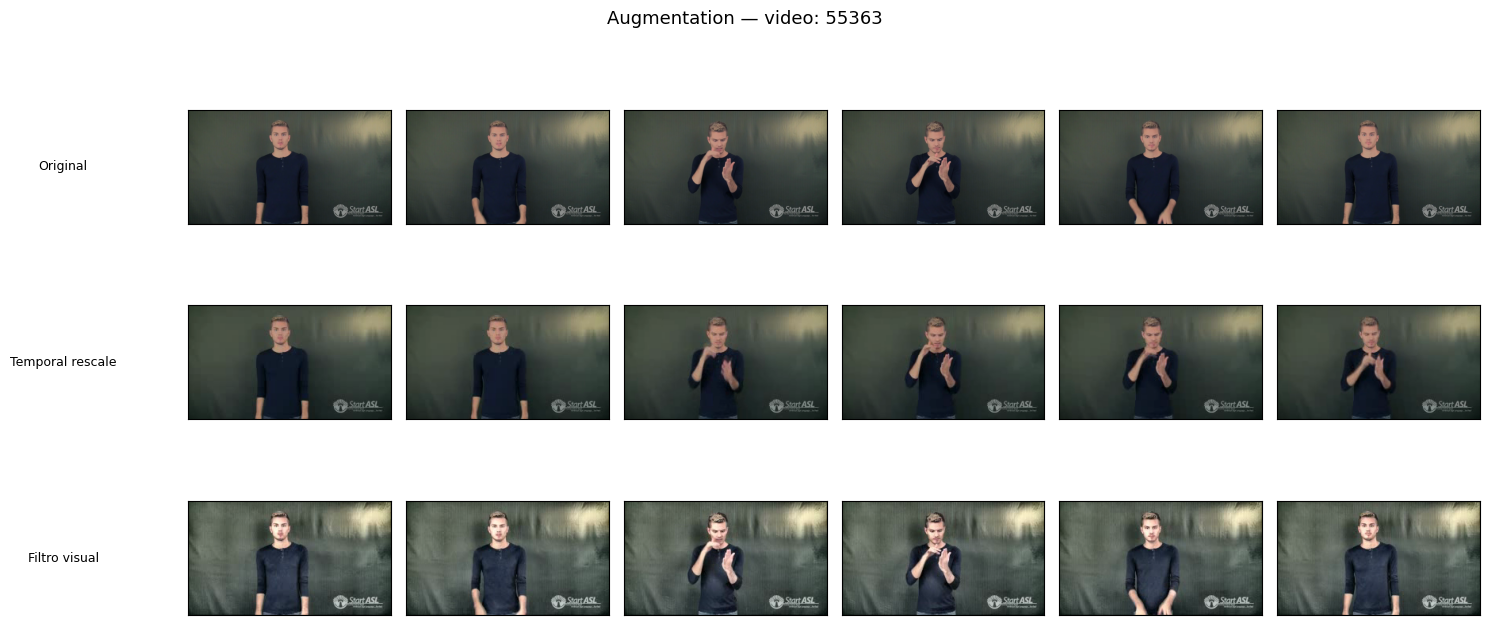

In [ ]:
show_augmentation_example(NSLT_AUG_JSON, VIDEOS_DIR, n_frames=6, seed=AUG_SEED, aug_seed=AUG_SEED)

## Entrenamiento I3D

Configurá los experimentos en la celda siguiente y corré el entrenamiento.
- `n_tune_layers=0` → fine-tuning completo (todos los pesos)
- `n_tune_layers=2` → solo la cabeza de clasificación (backbone congelado)
- `n_tune_layers=3` → Mixed_5c + cabeza
- `n_tune_layers=5` → Mixed_5b + MaxPool + Mixed_5c + cabeza
- `use_aug=True` → usa el JSON con datos augmentados (~534 clips de train)


In [26]:
import sys
for _p in [str(I3D_DIR), str(I3D_DIR / "datasets")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from train_i3d import train as train_i3d
import importlib, utils as _u; importlib.reload(_u)
from utils import plot_training_curves

WEIGHTS_PATH    = I3D_DIR / "weights" / "rgb_imagenet.pt"
CHECKPOINTS_DIR = I3D_DIR / "checkpoints"

assert WEIGHTS_PATH.exists(), f"Pesos no encontrados: {WEIGHTS_PATH}"
print(f"Pesos: {WEIGHTS_PATH}")
print(f"Checkpoints: {CHECKPOINTS_DIR}")


Pesos: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/weights/rgb_imagenet.pt
Checkpoints: /Users/luciadefrancesco/Downloads/SignBridge/WLASL/code/I3D/checkpoints


In [33]:
# Modificar esta celda para probar distintas configuraciones.
EXPERIMENTS = [
    #dict(name="full_ft",        n_tune_layers=0, lr=1e-3, batch_size=4, max_epochs=30, dropout=0.5, use_aug=False),
    dict(name="head_only",       n_tune_layers=2, lr=1e-3, batch_size=4, max_epochs=30, dropout=0.5, use_aug=False),
    #dict(name="partial_Mixed5c", n_tune_layers=3, lr=5e-4, batch_size=4, max_epochs=30, dropout=0.5, use_aug=False),
    #dict(name="full_ft_aug",     n_tune_layers=0, lr=1e-3, batch_size=4, max_epochs=30, dropout=0.5, use_aug=True),
]


In [ ]:
all_histories = {}

for exp in EXPERIMENTS:
    cfg     = dict(exp)
    use_aug = cfg.pop("use_aug")
    name    = cfg.pop("name")
    split   = NSLT_AUG_JSON if use_aug else NSLT_JSON
    print("\n" + "="*55)
    history = train_i3d(
        videos_dir=VIDEOS_DIR,
        split_json=split,
        weights_path=WEIGHTS_PATH,
        save_dir=CHECKPOINTS_DIR,
        experiment_name=name,
        **cfg,
    )
    all_histories[name] = history

print("\nEntrenamiento finalizado.")



[head_only] device=mps  lr=0.001  partial freeze (n_tune_layers=2)
Skipped videos:  0
214
Skipped videos:  0
36
  classes=20  train=214  val=36
  Epoch   1/30  loss=0.2764/0.2078  acc=0.042/0.028


In [ ]:
plot_training_curves(all_histories)

## Fusión I3D + TGCN (Pose)

Estrategia:
1. TGCN preentrenado en WLASL2000 → extractor de features de pose, congelado
2. I3D fine-tuneado → extractor de features de video, congelado
3. Concatenación


In [ ]:
import json as _json, sys
from pathlib import Path

TGCN_DIR  = NB_DIR / "TGCN"
POSE_ROOT = WLASL_DIR / "data" / "pose_per_individual_videos"

for _p in [str(TGCN_DIR), str(I3D_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# Cambiar al nombre del experimento que quieras usar como extractor de video
BEST_I3D_EXPERIMENT = "head_only"
I3D_CKPT  = CHECKPOINTS_DIR / f"{BEST_I3D_EXPERIMENT}_best.pt"
TGCN_CKPT = TGCN_DIR / "archived" / "asl2000" / "ckpt.pth"

assert I3D_CKPT.exists(),  f"Checkpoint I3D no encontrado: {I3D_CKPT}"
assert TGCN_CKPT.exists(), f"Checkpoint TGCN no encontrado: {TGCN_CKPT}"
print(f"I3D  : {I3D_CKPT}")
print(f"TGCN : {TGCN_CKPT}")
print(f"Poses: {POSE_ROOT}")


In [ ]:
import torch
import json as _json
import importlib, concat as _concat_mod; importlib.reload(_concat_mod)
from concat import load_pose_sequence, extract_tgcn_features
from tgcn_model import GCN_muti_att

TGCN_NUM_SAMPLES = 50

tgcn = GCN_muti_att(input_feature=TGCN_NUM_SAMPLES*2, hidden_feature=256,
                    num_class=2000, p_dropout=0.3, num_stage=24)
tgcn.load_state_dict(torch.load(str(TGCN_CKPT), map_location="cpu"))
tgcn.eval()

tgcn_features, tgcn_labels, tgcn_splits = extract_tgcn_features(
    tgcn, GLOSSES_VALID_JSON, POSE_ROOT, num_frames=TGCN_NUM_SAMPLES)
tgcn_vids = list(tgcn_features.keys())


In [ ]:
from concat import extract_i3d_features
from pytorch_i3d import InceptionI3d
import json as _json

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
num_classes = len(_json.loads(GLOSSES_VALID_JSON.read_text()))

i3d_ext = InceptionI3d(400, in_channels=3)
i3d_ext.replace_logits(num_classes)
i3d_ext.load_state_dict(torch.load(str(I3D_CKPT), map_location="cpu"))
i3d_ext.eval().to(device)

i3d_features, i3d_labels, i3d_splits = extract_i3d_features(
    i3d_ext, NSLT_JSON, VIDEOS_DIR, device)


### Setup: construir tensores de features

Los videos se dividen en **train+val** (para entrenar el MLP de fusión) y **test** (para evaluación final), igual que hace el I3D original.

Nota: el dataset tiene splits `train`, `val` y `test`. El código del I3D usa train+val juntos para entrenar y test para evaluar, así que replicamos esa convención para que los resultados sean comparables.

In [ ]:
import importlib, concat as _cm; importlib.reload(_cm)
from concat import (
    build_split_tensors, train_fusion_head,
    train_projection_fusion, train_bilinear_fusion,
)

common_vids = [v for v in tgcn_vids if v in i3d_features]
Xtr_t, Xtr_i, Xtr_f, ytr, Xte_t, Xte_i, Xte_f, yte = build_split_tensors(
    common_vids, tgcn_features, i3d_features, tgcn_labels, tgcn_splits)

TGCN_DIM, I3D_DIM = 256, 1024
all_results = {}
print(f"Tensores listos — train: {len(ytr)} | test: {len(yte)}")


### Baseline: solo TGCN (pose)

MLP entrenado únicamente sobre los features de pose (256-dim) del TGCN preentrenado en WLASL2000. Sirve como referencia para ver cuánto aporta la información esqueletal por sí sola.

In [ ]:
all_results["TGCN"] = train_fusion_head(
    Xtr_t, ytr, Xte_t, yte,
    in_dim=TGCN_DIM, num_classes=num_classes, name="TGCN")


### Baseline: solo I3D (video)

MLP entrenado únicamente sobre los features de video (1024-dim) del I3D fine-tuneado. Referencia para ver cuánto aporta la modalidad visual sola.

In [ ]:
all_results["I3D"] = train_fusion_head(
    Xtr_i, ytr, Xte_i, yte,
    in_dim=I3D_DIM, num_classes=num_classes, name="I3D")


### Fusión 1: Concatenación (1280-dim)

Los vectores de TGCN (256) e I3D (1024) se pegan directamente y un MLP aprende sobre los 1280 valores combinados.

**Ventaja:** simple y sin supuestos sobre cómo interactúan las modalidades.  
**Desventaja:** el I3D domina implícitamente por ser 4× más grande.

In [ ]:
all_results["Concat"] = train_fusion_head(
    Xtr_f, ytr, Xte_f, yte,
    in_dim=TGCN_DIM+I3D_DIM, num_classes=num_classes, name="Concat")


### Fusión 2: Proyección a espacio compartido + suma

Cada modalidad se proyecta a 512-dim con una capa lineal propia y los vectores resultantes se suman antes del clasificador.

**Ventaja:** ambas modalidades contribuyen simétricamente sin importar su dimensión original; el modelo aprende qué información de cada una retener.  
**Desventaja:** la suma supone que las contribuciones son aditivas, sin capturar interacciones entre ellas.

In [ ]:
all_results["Proj+Suma"] = train_projection_fusion(
    Xtr_t, Xtr_i, ytr, Xte_t, Xte_i, yte,
    tgcn_dim=TGCN_DIM, i3d_dim=I3D_DIM, num_classes=num_classes,
    name="Proj+Suma", shared_dim=512)


### Fusión 3: Bilinear compacto (producto de Hadamard)

Ambas modalidades se proyectan a 512-dim y se multiplican elemento a elemento (producto de Hadamard) antes del clasificador.

**Ventaja:** captura interacciones *multiplicativas* entre modalidades que la suma y la concatenación no pueden representar. Ejemplo: "este movimiento de mano (pose) EN ESTE contexto visual (I3D)".  
**Desventaja:** si una proyección colapsa a cero, anula la otra; puede necesitar regularización más fuerte.

In [ ]:
all_results["Bilinear"] = train_bilinear_fusion(
    Xtr_t, Xtr_i, ytr, Xte_t, Xte_i, yte,
    tgcn_dim=TGCN_DIM, i3d_dim=I3D_DIM, num_classes=num_classes,
    name="Bilinear", latent_dim=512)


### Comparación final

In [ ]:
print("=" * 40)
for name, acc in all_results.items():
    print(f"{name:<20}: {acc:.3f}")


## Módulo de Boca — Extracción de crops con MediaPipe

Extraemos la región de la boca de cada video como modalidad adicional. El objetivo es testear si el movimiento labial (*mouthing*) aporta información complementaria a la pose y al video completo.

Pipeline:
1. **MediaPipe FaceLandmarker** detecta 478 landmarks faciales por frame
2. Del subconjunto de landmarks del contorno de labios se computa un bbox
3. Se samplea un crop de `MOUTH_N_FRAMES` frames uniformes del video
4. Cada crop se redimensiona a `MOUTH_CROP_SIZE × MOUTH_CROP_SIZE` px

Los crops se guardan en disco la primera vez para no recomputar.

> **Nota sobre los frames:** el extractor samplea N frames *uniformemente* a lo largo del video entero — no frame a frame. Con 16 frames capturamos el movimiento general de la boca; subir a 32 da más resolución temporal pero cuadruplica el tamaño del tensor.

In [ ]:
import importlib, mouth_features as _mf; importlib.reload(_mf)
from mouth_features import MouthCropExtractor, extract_all_mouth_crops

MOUTH_MODEL    = NB_DIR / "face_landmarker.task"
MOUTH_CACHE    = NB_DIR / "mouth_crops.pt"
MOUTH_N_FRAMES = 16    # frames a samplear por video
MOUTH_CROP_SIZE = 64   # tamaño del crop cuadrado en píxeles
MOUTH_PAD      = 20    # padding alrededor del bbox de labios

assert MOUTH_MODEL.exists(), f"Modelo no encontrado: {MOUTH_MODEL}"
print(f"Modelo FaceLandmarker : {MOUTH_MODEL}")
print(f"Cache                 : {MOUTH_CACHE}")
print(f"Frames por video      : {MOUTH_N_FRAMES}")
print(f"Tamaño del crop       : {MOUTH_CROP_SIZE}x{MOUTH_CROP_SIZE} px")


In [ ]:
import torch

if MOUTH_CACHE.exists():
    saved = torch.load(str(MOUTH_CACHE), map_location="cpu")
    mouth_crops  = saved["crops"]
    mouth_labels = saved["labels"]
    mouth_splits = saved["splits"]
    print(f"Cargado desde cache: {len(mouth_crops)} videos")
else:
    mouth_crops, mouth_labels, mouth_splits = extract_all_mouth_crops(
        glosses_json=str(GLOSSES_VALID_JSON),
        videos_dir=str(VIDEOS_DIR),
        model_path=str(MOUTH_MODEL),
        n_frames=MOUTH_N_FRAMES,
        crop_size=MOUTH_CROP_SIZE,
        pad=MOUTH_PAD,
        save_path=str(MOUTH_CACHE),
    )

sample = next(iter(mouth_crops.values()))
print(f"Shape por video: {sample.shape}  dtype: {sample.dtype}")
print(f"  {MOUTH_N_FRAMES} frames × {MOUTH_CROP_SIZE}px × {MOUTH_CROP_SIZE}px × 3 canales RGB")


### Ejemplo de crop de boca

In [ ]:
import matplotlib.pyplot as plt
import random, json as _json

random.seed(42)
vid_id = random.choice(list(mouth_crops.keys()))
gloss_map = {str(inst["video_id"]): entry["gloss"]
             for entry in _json.loads(GLOSSES_VALID_JSON.read_text())
             for inst in entry["instances"]}
gloss = gloss_map.get(str(vid_id), "?")

frames = mouth_crops[vid_id]  # (n_frames, H, W, 3)
n_show = min(8, MOUTH_N_FRAMES)
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2, 2.5))
fig.suptitle(f"Crops de boca — video: {vid_id} ({gloss})", fontsize=11)
step = MOUTH_N_FRAMES // n_show
for i, ax in enumerate(axes):
    ax.imshow(frames[i * step])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"f{i*step}", fontsize=8)
plt.tight_layout()
plt.show()


### Encoding de boca: MobileNetV2 → 1280-dim

Cada crop de `(16, 64, 64, 3)` pasa frame a frame por MobileNetV2 congelado (preentrenado en ImageNet). La salida de la última capa convolucional se hace AdaptiveAvgPool → (1280,) por frame. Luego se promedian los 16 frames → **un vector de 1280-dim por video**.

MobileNetV2 está completamente congelado: no se actualizan sus pesos. Solo aprendemos cómo combinar ese vector con I3D y TGCN.

In [ ]:
import importlib, mouth_features as _mf; importlib.reload(_mf)
from mouth_features import encode_mouth_crops

MOUTH_FEATURES_CACHE = NB_DIR / "mouth_features.pt"

if MOUTH_FEATURES_CACHE.exists():
    mouth_feat = torch.load(str(MOUTH_FEATURES_CACHE), map_location="cpu")
    print(f"Cargado desde cache: {len(mouth_feat)} videos")
else:
    mouth_feat = encode_mouth_crops(mouth_crops, device=device)
    torch.save(mouth_feat, str(MOUTH_FEATURES_CACHE))
    print(f"Guardado en: {MOUTH_FEATURES_CACHE}")

MOUTH_DIM = next(iter(mouth_feat.values())).shape[0]
print(f"Dim boca: {MOUTH_DIM}")


## Fusión trimodal: TGCN + I3D + Boca

Repetimos los mismos experimentos de fusión pero con una 3ra modalidad: los features de boca (1280-dim). La pregunta es si el movimiento labial aporta información adicional a lo que ya capturan el esqueleto y el video.

La comparación directa es:
- Sin boca: resultados de la sección anterior
- Con boca: mismas fusiones + modalidad de boca

Solo se usan los videos que tienen las **3 fuentes** disponibles (TGCN pose + I3D video + crops de boca detectados).

In [ ]:
import importlib, concat as _cm; importlib.reload(_cm)
from concat import (
    build_trimodal_split_tensors,
    train_trimodal_projection_fusion,
    train_trimodal_bilinear_fusion,
)

# Videos presentes en las 3 modalidades
common_3 = [v for v in common_vids if v in mouth_feat]
print(f"Videos con 3 modalidades: {len(common_3)} (de {len(common_vids)} con TGCN+I3D)")

(
    Xtr_t3, Xtr_i3, Xtr_m3, Xtr_f3, ytr3,
    Xte_t3, Xte_i3, Xte_m3, Xte_f3, yte3,
) = build_trimodal_split_tensors(
    common_3, tgcn_features, i3d_features, mouth_feat,
    tgcn_labels, tgcn_splits)

all_results_3m = {}


### Concatenación 3-way (256 + 1024 + 1280 = 2560-dim)

Los 3 vectores se pegan directamente. El MLP tiene que aprender a pesar las 3 fuentes, pero la boca ya viene más "pesada" (1280 > 1024 > 256).

In [ ]:
all_results_3m["Concat+Boca"] = train_fusion_head(
    Xtr_f3, ytr3, Xte_f3, yte3,
    in_dim=TGCN_DIM + I3D_DIM + MOUTH_DIM,
    num_classes=num_classes, name="Concat+Boca")


### Proyección + suma 3-way

Cada modalidad se proyecta a 512-dim con su propia capa lineal y los 3 vectores resultantes se suman. Aquí la boca contribuye simétricamente a las otras dos, sin importar su dimensión original.

In [ ]:
all_results_3m["Proj+Suma+Boca"] = train_trimodal_projection_fusion(
    Xtr_t3, Xtr_i3, Xtr_m3, ytr3,
    Xte_t3, Xte_i3, Xte_m3, yte3,
    tgcn_dim=TGCN_DIM, i3d_dim=I3D_DIM, mouth_dim=MOUTH_DIM,
    num_classes=num_classes, name="Proj+Suma+Boca", shared_dim=512)


### Bilinear 3-way (Hadamard triple)

Las 3 modalidades se proyectan a 512-dim y se multiplican elemento a elemento: `z = proj_pose ⊙ proj_video ⊙ proj_boca`.

Captura interacciones entre las 3 fuentes: por ejemplo, "esta forma de mano (pose) en este contexto visual (I3D) con este movimiento labial (boca)" como señal conjunta.

In [ ]:
all_results_3m["Bilinear+Boca"] = train_trimodal_bilinear_fusion(
    Xtr_t3, Xtr_i3, Xtr_m3, ytr3,
    Xte_t3, Xte_i3, Xte_m3, yte3,
    tgcn_dim=TGCN_DIM, i3d_dim=I3D_DIM, mouth_dim=MOUTH_DIM,
    num_classes=num_classes, name="Bilinear+Boca", latent_dim=512)


### Comparación final: sin boca vs. con boca

In [ ]:
pairs = [
    ("TGCN",        None),
    ("I3D",         None),
    ("Concat",      "Concat+Boca"),
    ("Proj+Suma",   "Proj+Suma+Boca"),
    ("Bilinear",    "Bilinear+Boca"),
]

print(f"{"Fusión":<22} {"Sin boca":>10} {"Con boca":>10} {"Δ":>8}")
print("-" * 54)
for base, with_mouth in pairs:
    acc_base  = all_results.get(base, float("nan"))
    acc_mouth = all_results_3m.get(with_mouth, float("nan")) if with_mouth else float("nan")
    delta = acc_mouth - acc_base if with_mouth else float("nan")
    delta_str = f"{delta:+.3f}" if with_mouth else "  —"
    mouth_str = f"{acc_mouth:.3f}" if with_mouth else "  —"
    print(f"{base:<22} {acc_base:>10.3f} {mouth_str:>10} {delta_str:>8}")
